In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tidy3d as td
import tidy3d.web as web
import xarray as xr

In [2]:
# basic parameters of simulation setups
r1 = 0.2  # um
r0 = 0.5  # um
r2 = 0.9  # um
conductivity1 = 15  # W / (um * K)
conductivity2 = 2  # W / (um * K)
source1 = 600  # J / (um^3 * K)
source1c = 400
source2 = 300 # J / (um^3 * K)
source2c = 800
temperature1 = 310  # K
temperature2 = 300  # K

In [3]:
medium1 = td.Medium(
    heat_spec=td.SolidSpec(
        capacity=1,
        conductivity=conductivity1,
    ),
    name="solid1",
)

medium2 = td.Medium(
    heat_spec=td.SolidSpec(
        capacity=1,
        conductivity=conductivity2,
    ),
    name="solid2",
)

background_medium = td.Medium(
    heat_spec=td.FluidSpec(),
    name="fluid",
)

In [4]:
cyl_top_layer = td.Structure(
    geometry=td.Cylinder(center=(0, 0, 0), length=1, radius=r2),
    medium=medium2,
    name="top_layer",
)

cyl_bottom_layer = td.Structure(
    geometry=td.Cylinder(center=(0, 0, 0), length=1, radius=r0),
    medium=medium1,
    name="bottom_layer",
)

cyl_core = td.Structure(
    geometry=td.Cylinder(center=(0, 0, 0), length=1, radius=r1),
    medium=background_medium,
    name="core",
)

scene_cyl = td.Scene(
    structures=[cyl_top_layer, cyl_bottom_layer, cyl_core],
    medium=background_medium,
)

19:52:13 PDT WARNING: The function 'plot_heat_conductivity' is deprecated and   
             will be discontinued. In its place you can use                     
             plot_heat_charge_property(property="heat_conductivity")            

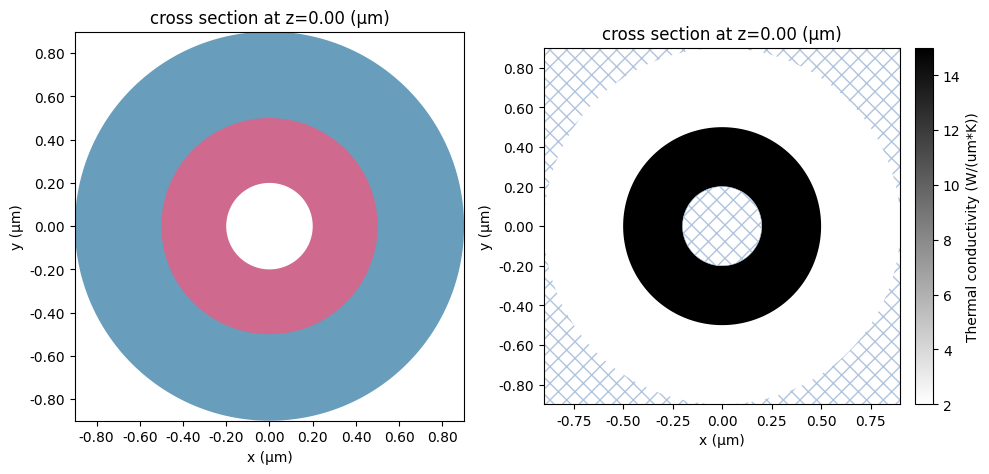

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
scene_cyl.plot(z=0, ax=ax[0])
scene_cyl.plot_heat_conductivity(z=0, ax=ax[1])
plt.tight_layout()
plt.show()

In [6]:
# simulation domain parameters
cyl_sim_center = (0, 0, 0)
cyl_sim_size = (2, 2, 0)

In [7]:
bc_side = td.HeatBoundarySpec(
    condition=td.HeatFluxBC(flux=0),
    placement=td.SimulationBoundary(),
)

bc_top = td.HeatBoundarySpec(
    condition=td.TemperatureBC(temperature=temperature2),
    placement=td.StructureBoundary(structure="top_layer"),
)

bc_bottom = td.HeatBoundarySpec(
    condition=td.TemperatureBC(temperature=temperature1),
    placement=td.StructureStructureInterface(structures=["core", "bottom_layer"]),
)

Note also that, for example, in case of `bc_bottom` we could have equivalently set `placement` to be `td.StructureBoundary(structure="core")` or `td.MediumMediumInterface(mediums=["solid1", "fluid"])`.

In [8]:
q1 = lambda r: source1 + source1c / r ** 3
Q1 = lambda r: source1 * r ** 2 / 4 + source1c / r 
Q1r = lambda r: source1 * r / 2 - source1c / r ** 2

q2 = lambda r: source2 + source2c * r ** 2
Q2 = lambda r: source2 * r ** 2 / 4 + source2c * r ** 4 / 16
Q2r = lambda r: source2 * r / 2 + source2c * r ** 3 / 4

In [9]:
temp_mnt = td.TemperatureMonitor(
    center=(0, 0, 0), size=(td.inf, td.inf, 0), name="temperature", unstructured=True
)

In [10]:
def make_sim(res):
    x = np.linspace(-1, 1, int(2/(res)))
    y = np.linspace(-1, 1, int(2/(res)))
    z = np.zeros(1)
    
    X, Y, Z = np.meshgrid(x, y, z, indexing="ij")
    
    r = np.sqrt(X ** 2 + Y ** 2) + 1e-20
    
    source1_custom_data = td.SpatialDataArray(q1(r), coords=dict(x=x, y=y, z=z))
    source2_custom_data = td.SpatialDataArray(q2(r), coords=dict(x=x, y=y, z=z))
    
    source_bottom = td.HeatSource(structures=["bottom_layer"], rate=source1_custom_data)
    source_top = td.HeatSource(structures=["top_layer"], rate=source2_custom_data)
    
    heat_sim_cyl = td.HeatChargeSimulation.from_scene(
        center=cyl_sim_center,
        size=cyl_sim_size,
        scene=scene_cyl,
        boundary_spec=[bc_top, bc_bottom, bc_side],
        sources=[source_bottom, source_top],
        # grid_spec=td.UniformUnstructuredGrid(dl=0.02),
        grid_spec=td.DistanceUnstructuredGrid(dl_bulk=res, dl_interface=res, distance_bulk=1, distance_interface=1),
        monitors=[temp_mnt],
        symmetry=(1, 1, 0),
    )
    return heat_sim_cyl

In [11]:
res_all = [0.04, 0.02, 0.01, 0.005]

In [12]:
heat_sim_cyl_all = {str(res): make_sim(res) for res in res_all}

In [14]:
from tidy3d import web
batch = web.Batch(simulations=heat_sim_cyl_all, solver_version="custom-heat-source-0.0.0")
heat_sim_data_cyl_all = batch.run()

Output()

19:52:26 PDT Started working on Batch containing 4 tasks.

19:52:54 PDT Maximum FlexCredit cost: 0.100 for the whole batch.

             Use 'Batch.real_cost()' to get the billed FlexCredit cost after the
             Batch has completed.

Output()

19:54:13 PDT Batch complete.

Output()

In [15]:
heat_sim_data_cyl = heat_sim_data_cyl_all["0.02"]

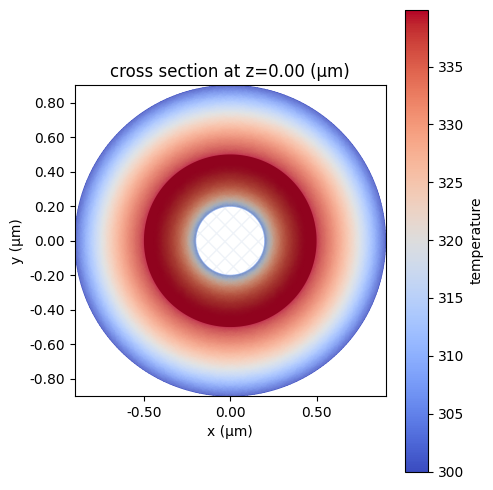

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

heat_sim_data_cyl.plot_field("temperature", ax=ax)

plt.tight_layout()
plt.show()

In [17]:
# green functions of steady state heat equation
u = lambda r: np.log(r)
# and its derivative
du = lambda r: 1.0 / r

In [18]:
def get_coeffs(u, du, N):
    """A helper function that finds coefficients of analytical solution in N dimensions."""

    # construct matrix
    mat = [
        [u(r1), 1, 0, 0],
        [0, 0, u(r2), 1],
        [u(r0), 1, -u(r0), -1],
        [conductivity1 * du(r0), 0, -conductivity2 * du(r0), 0],
    ]

    # construct right-hand side
    rhs = [
        temperature1 + Q1(r1) / conductivity1,
        temperature2 + Q2(r2) / conductivity2,
        (Q1(r0) / conductivity1 - Q2(r0) / conductivity2) ,
        Q1r(r0) - Q2r(r0),
    ]

    A1, B1, B2, A2 = np.linalg.solve(mat, rhs)

    return A1, B1, B2, A2

In [19]:
def get_analytical(N, x, u, du):
    """A helper function that samples N-dimensional analytical solution at coordinates x."""

    A1, B1, A2, B2 = get_coeffs(u, du, N)

    x1_inds = np.abs(x) < r0
    x2_inds = np.abs(x) >= r0

    T = np.zeros_like(x)

    x1 = x[x1_inds]
    x2 = x[x2_inds]

    T[x1_inds] = -Q1(x[x1_inds]) / conductivity1 + A1 * u(np.abs(x[x1_inds])) + B1
    T[x2_inds] = -Q2(x[x2_inds]) / conductivity2 + A2 * u(np.abs(x[x2_inds])) + B2

    return T

In [20]:
max_errors_all = []
avg_errors_all = []
for data in heat_sim_data_cyl_all.values():
    temp_numerical = data["temperature"].temperature
    r = np.linalg.norm(temp_numerical.points, axis=1)
    temp_exact_values = get_analytical(2, r, u, du)
    error = np.abs(temp_numerical.values.data -temp_exact_values)
    max_errors_all.append(np.max(error))
    avg_errors_all.append(np.mean(error))

Text(0.5, 0, 'Resolution, au')

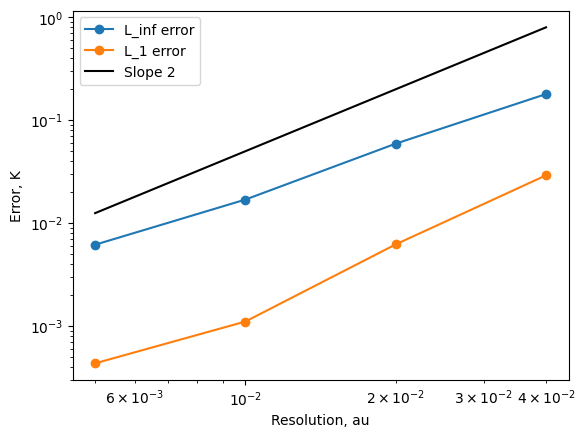

In [21]:
plt.loglog(res_all, max_errors_all, '-o')
plt.loglog(res_all, avg_errors_all, '-o')
plt.loglog(res_all, 500 * np.power(res_all, 2), '-k')
plt.legend(["L_inf error", "L_1 error", "Slope 2"])
plt.ylabel("Error, K")
plt.xlabel("Resolution, au")

In [22]:
temp_exact = temp_numerical.updated_copy(values=td.IndexedDataArray(temp_exact_values, dims=["index"]))

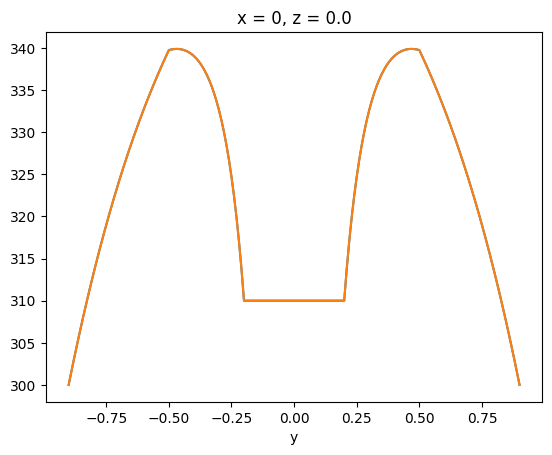

In [23]:
temp_exact.plane_slice(axis=0, pos=0).plot()
temp_numerical.plane_slice(axis=0, pos=0).plot()

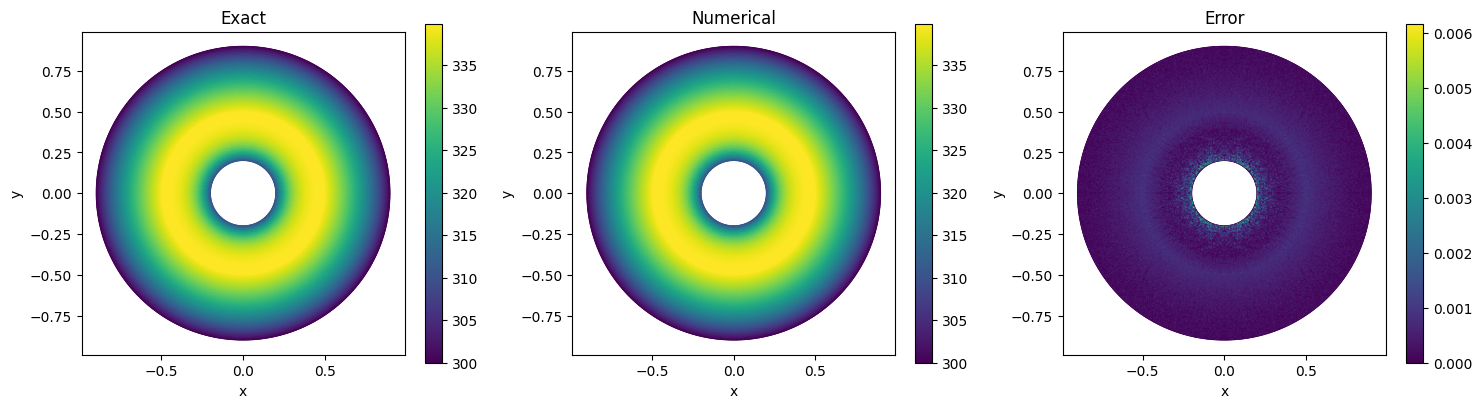

In [24]:
_, ax = plt.subplots(1, 3, figsize=(15, 4))

temp_exact.plot(grid=False, ax=ax[0])
ax[0].set_title("Exact")

temp_numerical.plot(grid=False, ax=ax[1])
ax[1].set_title("Numerical")

error = (temp_exact - temp_numerical).abs
error.plot(grid=False, ax=ax[2])
ax[2].set_title("Error")

plt.tight_layout()
plt.show()